# Laboratorio 01 — Pingüinos

**Estudiante:** Montoya_829

Este notebook analiza el archivo local `data/penguins.csv`. Los resultados describen la muestra y no permiten establecer relaciones causales.

## Fase 1 — A. Carga y observación inicial

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:.2f}')

DATA_PATH = Path('data/penguins.csv')
df = pd.read_csv(DATA_PATH)
numeric_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_columns = ['species', 'island', 'sex']
print(f'Archivo cargado: {DATA_PATH}')

Archivo cargado: data/penguins.csv


In [2]:
print(f'Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.')
display(df.head())

Dimensiones: 344 filas y 7 columnas.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10,18.70,181.00,3750.00,MALE
1,Adelie,Torgersen,39.50,17.40,186.00,3800.00,FEMALE
2,Adelie,Torgersen,40.30,18.00,195.00,3250.00,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.70,19.30,193.00,3450.00,FEMALE


## Fase 1 — B. Perfil del conjunto de datos

Se revisan el esquema, los tipos de datos, valores faltantes, duplicados y variables categóricas de baja cardinalidad.

In [3]:
profile = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    'no_nulos': df.notna().sum(),
    'valores_unicos': df.nunique(dropna=True)
})
print('Perfil de columnas')
display(profile)
print(f'Filas duplicadas: {df.duplicated().sum()}')
low_cardinality = profile.loc[profile['valores_unicos'] <= 10, 'valores_unicos']
print('Variables de baja cardinalidad (hasta 10 valores):')
display(low_cardinality.to_frame('valores_unicos'))

Perfil de columnas


,tipo,faltantes,no_nulos,valores_unicos
species,object,0,344,3
island,object,0,344,3
bill_length_mm,float64,2,342,164
bill_depth_mm,float64,2,342,80
flipper_length_mm,float64,2,342,55
body_mass_g,float64,2,342,94
sex,object,11,333,2


Filas duplicadas: 0
Variables de baja cardinalidad (hasta 10 valores):


,valores_unicos
species,3
island,3
sex,2


## Fase 1 — C. Descriptivos

Las medidas numéricas se calculan con los valores disponibles. Los porcentajes categóricos incluyen los valores faltantes para mostrar su presencia cuando existe.

In [4]:
numeric_summary = df[numeric_columns].describe().T
numeric_summary['mediana'] = df[numeric_columns].median()
numeric_summary['IQR'] = df[numeric_columns].quantile(0.75) - df[numeric_columns].quantile(0.25)
numeric_summary = numeric_summary[['count', 'mean', 'mediana', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']]
print('Resumen de variables numéricas')
display(numeric_summary)

Resumen de variables numéricas


,count,mean,mediana,std,min,25%,50%,75%,max,IQR
bill_length_mm,342.00,43.92,44.45,5.46,32.10,39.23,44.45,48.50,59.60,9.27
bill_depth_mm,342.00,17.15,17.30,1.97,13.10,15.60,17.30,18.70,21.50,3.10
flipper_length_mm,342.00,200.92,197.00,14.06,172.00,190.00,197.00,213.00,231.00,23.00
body_mass_g,342.00,4201.75,4050.00,801.95,2700.00,3550.00,4050.00,4750.00,6300.00,1200.00


In [5]:
for column in categorical_columns:
    counts = df[column].fillna('Faltante').value_counts(dropna=False)
    summary = pd.DataFrame({
        'conteo': counts,
        'porcentaje': (counts / len(df) * 100).round(2)
    })
    print(f'\n{column}')
    display(summary)


species


,conteo,porcentaje
species,,
Adelie,152,44.19
Gentoo,124,36.05
Chinstrap,68,19.77



island


,conteo,porcentaje
island,,
Biscoe,168,48.84
Dream,124,36.05
Torgersen,52,15.12



sex


,conteo,porcentaje
sex,,
MALE,168,48.84
FEMALE,165,47.97
Faltante,11,3.20


In [6]:
cross_tables = {
    'Especie por isla': pd.crosstab(df['species'], df['island'], margins=True),
    'Especie por sexo': pd.crosstab(df['species'], df['sex'].fillna('Faltante'), margins=True),
    'Isla por sexo': pd.crosstab(df['island'], df['sex'].fillna('Faltante'), margins=True)
}
for name, table in cross_tables.items():
    print(f'\n{name}')
    display(table)


Especie por isla


island,Biscoe,Dream,Torgersen,All
species,,,,
Adelie,44,56,52,152
Chinstrap,0,68,0,68
Gentoo,124,0,0,124
All,168,124,52,344



Especie por sexo


sex,FEMALE,Faltante,MALE,All
species,,,,
Adelie,73,6,73,152
Chinstrap,34,0,34,68
Gentoo,58,5,61,124
All,165,11,168,344



Isla por sexo


sex,FEMALE,Faltante,MALE,All
island,,,,
Biscoe,80,5,83,168
Dream,61,1,62,124
Torgersen,24,5,23,52
All,165,11,168,344


In [7]:
pearson_matrix = df[numeric_columns].corr(method='pearson')
spearman_matrix = df[numeric_columns].corr(method='spearman')
print('Correlación de Pearson')
display(pearson_matrix)
print('Correlación de Spearman')
display(spearman_matrix)

Correlación de Pearson


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


Correlación de Spearman


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.22,0.67,0.58
bill_depth_mm,-0.22,1.00,-0.52,-0.43
flipper_length_mm,0.67,-0.52,1.00,0.84
body_mass_g,0.58,-0.43,0.84,1.00


### Interpretación de las correlaciones

Pearson resume relaciones lineales y Spearman resume relaciones monótonas a partir de rangos. Se comparan ambas matrices porque una relación puede conservar el orden aunque no sea exactamente lineal.

In [8]:
pearson_flipper_mass = pearson_matrix.loc['flipper_length_mm', 'body_mass_g']
spearman_flipper_mass = spearman_matrix.loc['flipper_length_mm', 'body_mass_g']
print(
    f'Entre longitud de aleta y masa corporal, Pearson fue {pearson_flipper_mass:.3f} y '
    f'Spearman fue {spearman_flipper_mass:.3f}. Ambos valores resumen una asociación positiva en la muestra. '
    'La correlación no identifica una causa y puede cambiar al separar las especies.'
)

Entre longitud de aleta y masa corporal, Pearson fue 0.871 y Spearman fue 0.840. Ambos valores resumen una asociación positiva en la muestra. La correlación no identifica una causa y puede cambiar al separar las especies.


## Fase 1 — D. Visualización

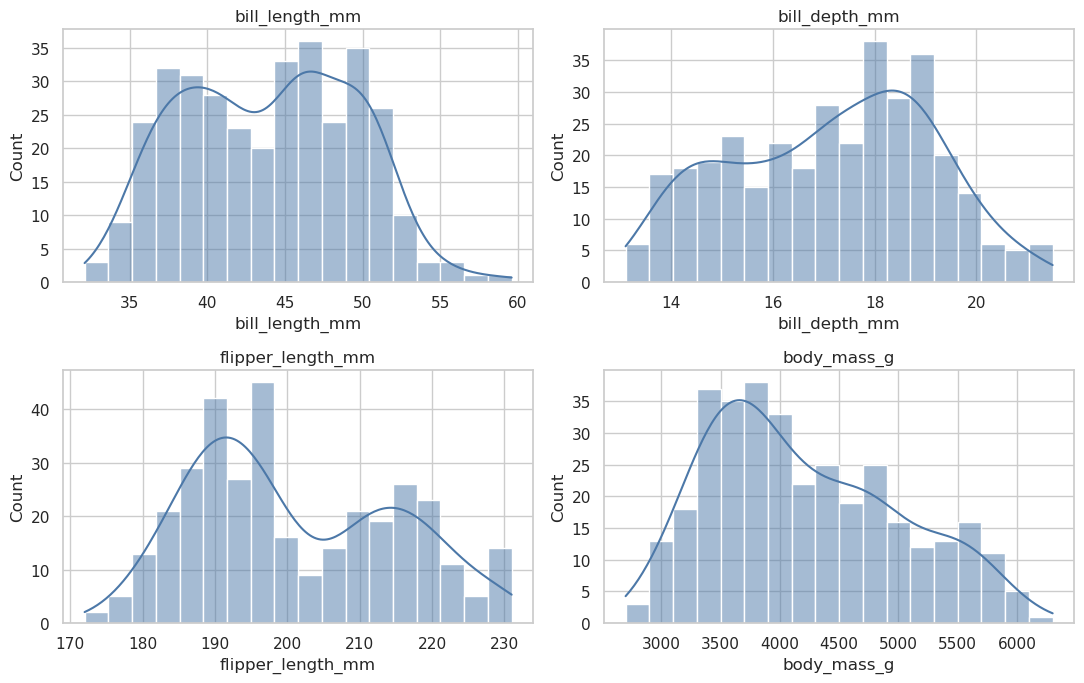

- bill_length_mm: forma aproximadamente simétrica.
- bill_depth_mm: forma aproximadamente simétrica.
- flipper_length_mm: ligera asimetría hacia valores altos.
- body_mass_g: ligera asimetría hacia valores altos.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
shape_descriptions = {}
for column, ax in zip(numeric_columns, axes.ravel()):
    values = df[column].dropna()
    sns.histplot(values, bins=18, kde=True, ax=ax, color='#4C78A8')
    ax.set_title(column)
    skewness = values.skew()
    if skewness > 0.30:
        description = 'ligera asimetría hacia valores altos'
    elif skewness < -0.30:
        description = 'ligera asimetría hacia valores bajos'
    else:
        description = 'forma aproximadamente simétrica'
    shape_descriptions[column] = description
plt.tight_layout()
plt.show()
plt.close(fig)
for column, description in shape_descriptions.items():
    print(f'- {column}: {description}.')

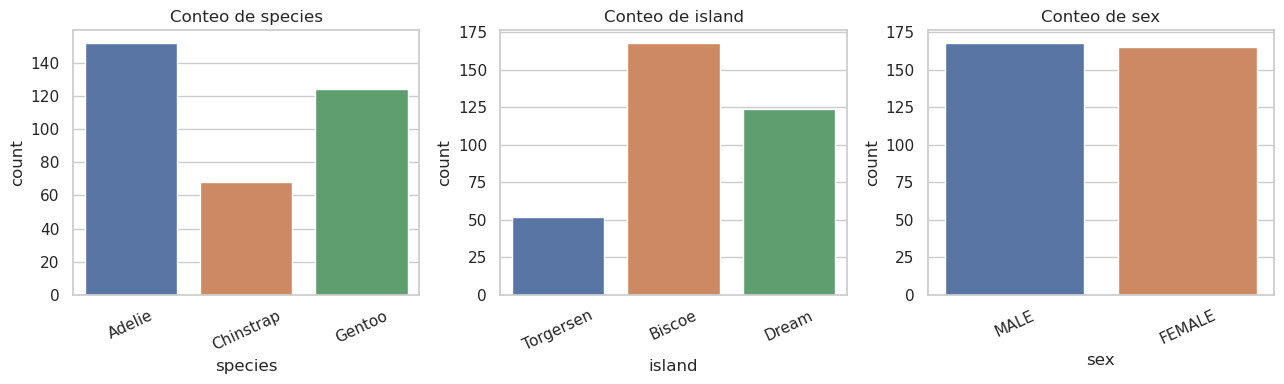

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for column, ax in zip(categorical_columns, axes):
    sns.countplot(data=df, x=column, hue=column, legend=False, ax=ax, palette='deep')
    ax.set_title(f'Conteo de {column}')
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()
plt.close(fig)

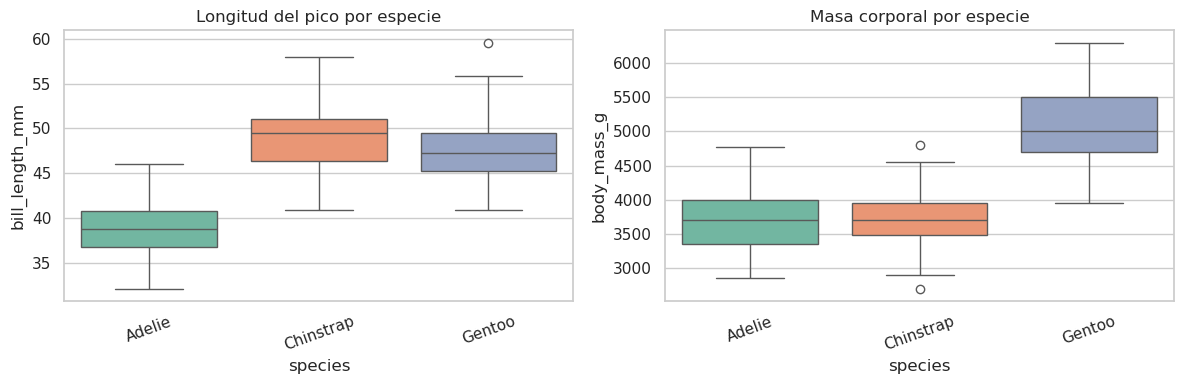

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='species', y='bill_length_mm', hue='species', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('Longitud del pico por especie')
sns.boxplot(data=df, x='species', y='body_mass_g', hue='species', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title('Masa corporal por especie')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
plt.close(fig)

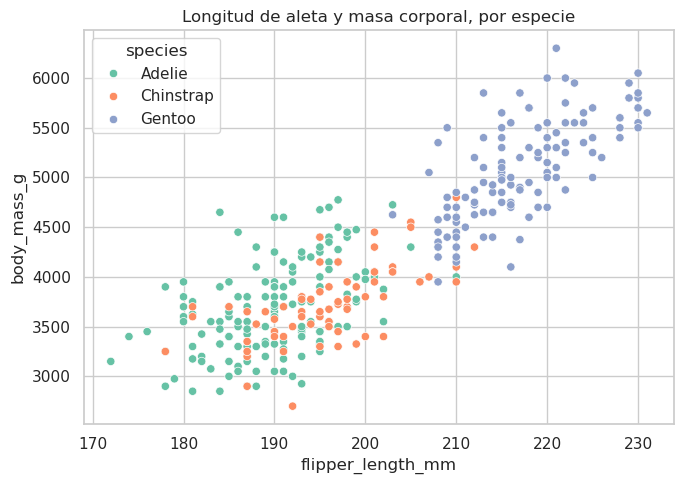

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df, x='flipper_length_mm', y='body_mass_g', hue='species',
    palette='Set2', ax=ax
)
ax.set_title('Longitud de aleta y masa corporal, por especie')
plt.tight_layout()
plt.show()
plt.close(fig)

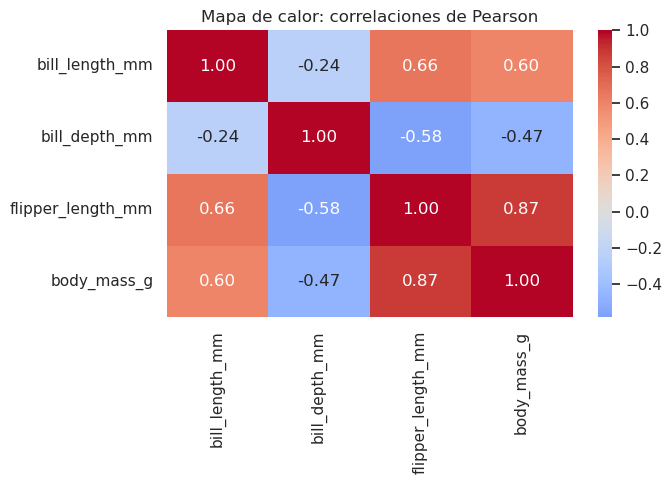

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pearson_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Mapa de calor: correlaciones de Pearson')
plt.tight_layout()
plt.show()
plt.close(fig)

## Fase 1 — E. Hipótesis y pruebas

1. **H1:** La longitud de aleta y la masa corporal tienen una asociación lineal en la muestra.
2. **H2:** La media de longitud del pico no es igual en todas las especies.
3. **H3:** La distribución de especies no es independiente de la isla.

Se usa un nivel de significancia de 0.05. Las conclusiones describen evidencia estadística y no causalidad.

In [14]:
alpha = 0.05

# H1: Pearson entre longitud de aleta y masa corporal
h1_data = df[['flipper_length_mm', 'body_mass_g']].dropna()
h1_r, h1_p = stats.pearsonr(h1_data['flipper_length_mm'], h1_data['body_mass_g'])
h1_conclusion = ('Se rechaza la hipótesis de correlación nula; hay evidencia de asociación lineal en la muestra.'
                 if h1_p < alpha else
                 'No se rechaza la hipótesis de correlación nula; la evidencia no es suficiente en la muestra.')

# H2: ANOVA de longitud del pico por especie
h2_data = df[['species', 'bill_length_mm']].dropna()
h2_groups = [group['bill_length_mm'].to_numpy() for _, group in h2_data.groupby('species')]
h2_f, h2_p = stats.f_oneway(*h2_groups)
h2_conclusion = ('Se rechaza la igualdad de medias; al menos una media de longitud del pico difiere entre especies.'
                 if h2_p < alpha else
                 'No se rechaza la igualdad de medias; no hay evidencia suficiente de diferencia entre especies.')

# H3: Chi-cuadrado entre especie e isla
h3_table = pd.crosstab(df['species'], df['island'])
h3_chi2, h3_p, h3_dof, _ = stats.chi2_contingency(h3_table)
h3_conclusion = ('Se rechaza la independencia; especie e isla están asociadas en esta muestra.'
                 if h3_p < alpha else
                 'No se rechaza la independencia; no hay evidencia suficiente de asociación en esta muestra.')

test_results = pd.DataFrame([
    {'hipótesis': 'H1', 'método': 'Pearson', 'estadístico': h1_r, 'p_valor': f'{h1_p:.3g}', 'n': len(h1_data)},
    {'hipótesis': 'H2', 'método': 'ANOVA de una vía', 'estadístico': h2_f, 'p_valor': f'{h2_p:.3g}', 'n': len(h2_data)},
    {'hipótesis': 'H3', 'método': 'Chi-cuadrado', 'estadístico': h3_chi2, 'p_valor': f'{h3_p:.3g}', 'n': int(h3_table.to_numpy().sum())}
])
display(test_results)
print(f'H1 — Pearson: r={h1_r:.3f}, p={h1_p:.3g}, n={len(h1_data)}. {h1_conclusion} No demuestra causalidad.')
print(f'H2 — ANOVA: F={h2_f:.3f}, p={h2_p:.3g}, n={len(h2_data)}. {h2_conclusion} No demuestra causalidad.')
print(f'H3 — Chi-cuadrado: χ²={h3_chi2:.3f}, gl={h3_dof}, p={h3_p:.3g}, n={int(h3_table.to_numpy().sum())}. {h3_conclusion} No demuestra causalidad.')

,hipótesis,método,estadístico,p_valor,n
0,H1,Pearson,0.87,4.37e-107,342
1,H2,ANOVA de una vía,410.60,2.69e-91,342
2,H3,Chi-cuadrado,299.55,1.35e-63,344


H1 — Pearson: r=0.871, p=4.37e-107, n=342. Se rechaza la hipótesis de correlación nula; hay evidencia de asociación lineal en la muestra. No demuestra causalidad.
H2 — ANOVA: F=410.600, p=2.69e-91, n=342. Se rechaza la igualdad de medias; al menos una media de longitud del pico difiere entre especies. No demuestra causalidad.
H3 — Chi-cuadrado: χ²=299.550, gl=4, p=1.35e-63, n=344. Se rechaza la independencia; especie e isla están asociadas en esta muestra. No demuestra causalidad.


## Fase 1 — F. Conclusiones

In [15]:
print('1. Descripción')
print(f'La base contiene {len(df)} filas, {df.duplicated().sum()} duplicados y valores faltantes en algunas medidas y en sexo.')
print('\n2. Hallazgos estadísticos respaldados')
print(f'La asociación entre longitud de aleta y masa corporal fue positiva (r={h1_r:.3f}, p={h1_p:.3g}).')
print(f'El ANOVA para longitud del pico por especie dio F={h2_f:.3f} con p={h2_p:.3g}.')
print(f'La prueba de especie e isla dio χ²={h3_chi2:.3f} con p={h3_p:.3g}.')
print('\n3. Limitaciones')
print('Estas pruebas describen asociaciones y diferencias en la muestra. No establecen causalidad, y la mezcla de especies puede cambiar la interpretación de relaciones globales.')

1. Descripción
La base contiene 344 filas, 0 duplicados y valores faltantes en algunas medidas y en sexo.

2. Hallazgos estadísticos respaldados
La asociación entre longitud de aleta y masa corporal fue positiva (r=0.871, p=4.37e-107).
El ANOVA para longitud del pico por especie dio F=410.600 con p=2.69e-91.
La prueba de especie e isla dio χ²=299.550 con p=1.35e-63.

3. Limitaciones
Estas pruebas describen asociaciones y diferencias en la muestra. No establecen causalidad, y la mezcla de especies puede cambiar la interpretación de relaciones globales.


### Preguntas para investigación humana

1. ¿Las diferencias observadas entre islas representan hábitats distintos o solo el lugar donde se tomaron las mediciones?
2. ¿Cómo afecta la ausencia de datos en `sex` a las comparaciones de masa corporal y tamaño?
3. ¿Qué variables de edad, temporada o condiciones ambientales ayudarían a interpretar las diferencias entre especies?

## Fase 2 — Reflexión asistida

- **Generator:** propone una hipótesis y una conclusión a partir de un resumen.
- **Critic:** revisa si la conclusión omite una variable importante o afirma más de lo que permiten los datos.
- **Reviewer:** repite el análisis necesario para responder a las objeciones del crítico.

El script existente realiza ese ciclo con el mismo archivo local.

In [16]:
import subprocess
import sys

completed = subprocess.run(
    [sys.executable, 'reflexive_analyst.py'],
    text=True, capture_output=True, check=True
)
print(completed.stdout.strip())
if completed.stderr.strip():
    print(completed.stderr.strip())

Registro creado en /home/juanm/002_EstudiantesAprendizajeEstadistico/semestre2026-2/Estudiantes/Montoya_829/Laboratorios/Lab_01_pinguinos/reflection_log.md con 2 ciclos.


In [17]:
reflection_path = Path('reflection_log.md')
print(reflection_path.read_text(encoding='utf-8'))

# Registro de reflexión

## Ciclo 1
**Hipótesis:** En la muestra completa, bill_length_mm y bill_depth_mm presentan una asociación lineal.
**Análisis ejecutado:** Se eliminaron filas con bill_length_mm o bill_depth_mm faltantes y se calculó Pearson sobre toda la muestra válida.
**Resultado numérico:** r=-0.235, p=1.12e-05, n=342
**Objeciones:**
- Se ignoró la variable de agrupación species; la relación debe revisarse por especie.
- La muestra completa puede ser heterogénea y mezclar especies puede ocultar diferencias.
**Bloqueante:** true
**Qué cambió:** Análisis inicial de la muestra completa.
**Conclusión:** En la muestra completa, la correlación de Pearson entre bill_length_mm y bill_depth_mm fue r=-0.235, p=1.12e-05 y n=342. Esto describe una asociación lineal del conjunto total y no demuestra causalidad.

## Ciclo 2
**Hipótesis:** La asociación entre las medidas puede cambiar entre especies.
**Análisis ejecutado:** Se usaron las filas numéricas válidas, se separaron por especie pa

In [18]:
comparison = pd.DataFrame({
    'Aspecto': ['Cálculo', 'Revisión', 'Resultado'],
    'Análisis clásico': [
        'Se calculan descriptivos, gráficos y pruebas en el notebook.',
        'La revisión depende de la lectura del análisis.',
        'Resume patrones y pruebas de la muestra.'
    ],
    'Reflexión asistida': [
        'El script calcula Pearson con datos locales.',
        'El crítico exige revisar la agrupación por especie.',
        'Deja un registro de los ciclos y cambios.'
    ]
})
display(comparison)

,Aspecto,Análisis clásico,Reflexión asistida
0,Cálculo,"Se calculan descriptivos, gráficos y pruebas e...",El script calcula Pearson con datos locales.
1,Revisión,La revisión depende de la lectura del análisis.,El crítico exige revisar la agrupación por esp...
2,Resultado,Resume patrones y pruebas de la muestra.,Deja un registro de los ciclos y cambios.


**Nota de interpretación:** al agrupar por `species`, cambia la interpretación de la relación entre `bill_length_mm` y `bill_depth_mm`. La relación observada en la muestra completa puede mezclar diferencias entre especies con los patrones dentro de cada especie.